In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
matches_df = pd.read_csv("matches.csv")

In [3]:
matches_df['season'].value_counts().sort_index()

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64

In [4]:
matches_df['season'].value_counts().sort_index()

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64

In [5]:
matches_df['toss_winner'].value_counts().idxmax()

'Mumbai Indians'

In [6]:
matches_df['toss_decision'].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

In [7]:
matches_df['player_of_match'].value_counts().head(10)

player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
DA Warner         17
RG Sharma         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

In [8]:
matches_df['venue'].value_counts().head(10)

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Dr DY Patil Sports Academy                    17
Name: count, dtype: int64

In [9]:
matches_df.groupby(['season', 'winner']).size().reset_index(name='wins') \
    .sort_values(['season', 'wins'], ascending=[True, False]) \
    .groupby('season').first().reset_index()

,season,winner,wins
0,2008,Rajasthan Royals,13
1,2009,Delhi Daredevils,10
2,2010,Mumbai Indians,11
3,2011,Chennai Super Kings,11
4,2012,Kolkata Knight Riders,12
5,2013,Mumbai Indians,13
6,2014,Kings XI Punjab,12
7,2015,Chennai Super Kings,10
8,2016,Sunrisers Hyderabad,11
9,2017,Mumbai Indians,12


In [14]:
matches_df[matches_df['win_by_runs'] > 0].groupby('winner') \
['win_by_runs'].apply(lambda x: np.mean(x.values))

winner
Chennai Super Kings            34.192308
Deccan Chargers                23.388889
Delhi Capitals                 30.666667
Delhi Daredevils               27.000000
Gujarat Lions                   1.000000
Kings XI Punjab                24.342105
Kochi Tuskers Kerala           11.500000
Kolkata Knight Riders          30.166667
Mumbai Indians                 32.736842
Pune Warriors                  23.166667
Rajasthan Royals               33.148148
Rising Pune Supergiant         24.600000
Rising Pune Supergiants        26.500000
Royal Challengers Bangalore    35.771429
Sunrisers Hyderabad            23.766667
Name: win_by_runs, dtype: float64

In [23]:
all_teams = matches_df['winner'].dropna().unique()

max = (
    matches_df[matches_df['win_by_runs'] > 0].groupby('winner') \
    ['win_by_runs'].apply(lambda x: np.max(x.values))
)

min = (
    matches_df[matches_df['win_by_runs'] > 0].groupby('winner') \
    ['win_by_runs'].apply(lambda x: np.min(x.values))
)

summary_df = pd.DataFrame({'Highest Runs': max, 'Lowest Runs': min})

display(summary_df)

,Highest Runs,Lowest Runs
winner,,
Chennai Super Kings,97,1
Deccan Chargers,82,6
Delhi Capitals,39,16
Delhi Daredevils,97,1
Gujarat Lions,1,1
Kings XI Punjab,111,1
Kochi Tuskers Kerala,17,6
Kolkata Knight Riders,140,2
Mumbai Indians,146,1


C:\Users\shour\AppData\Local\Temp\ipykernel_26020\1187021457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=season_counts.index, y=season_counts.values, palette="viridis")


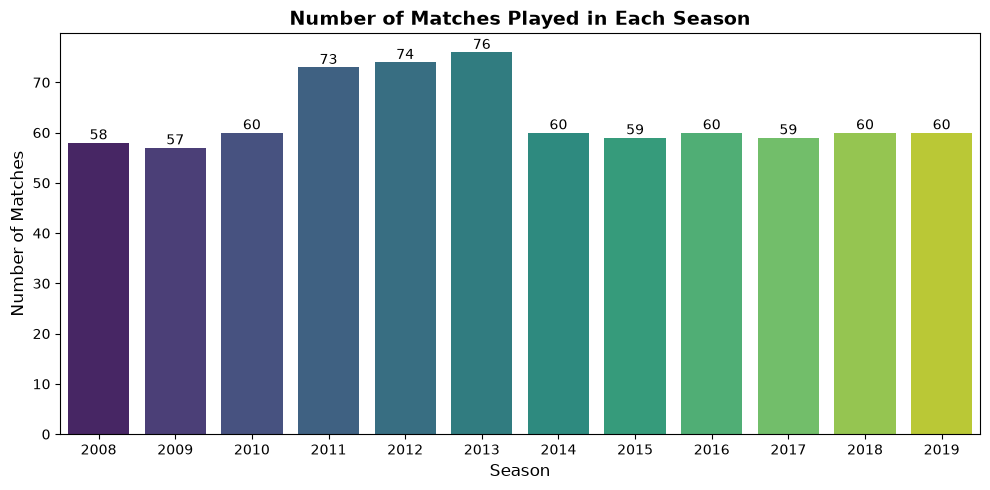

In [24]:
plt.figure(figsize=(10, 5))
season_counts = matches_df['season'].value_counts().sort_index()
ax = sns.barplot(x=season_counts.index, y=season_counts.values, palette="viridis")
plt.title("Number of Matches Played in Each Season", fontsize=14, fontweight='bold')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()